In [3]:
import pandas as pd

consumer = pd.read_csv("kafka-consumer/kafka_metrics.csv")
loader = pd.read_csv("trace-loader/rate_log.csv")

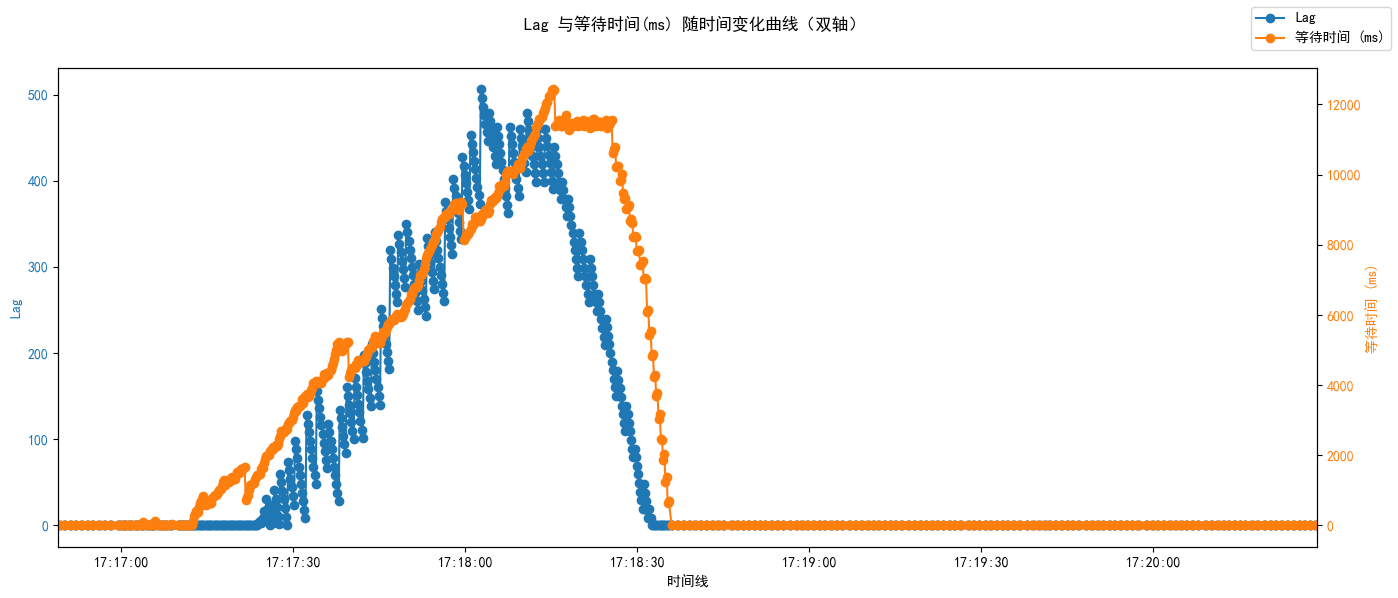

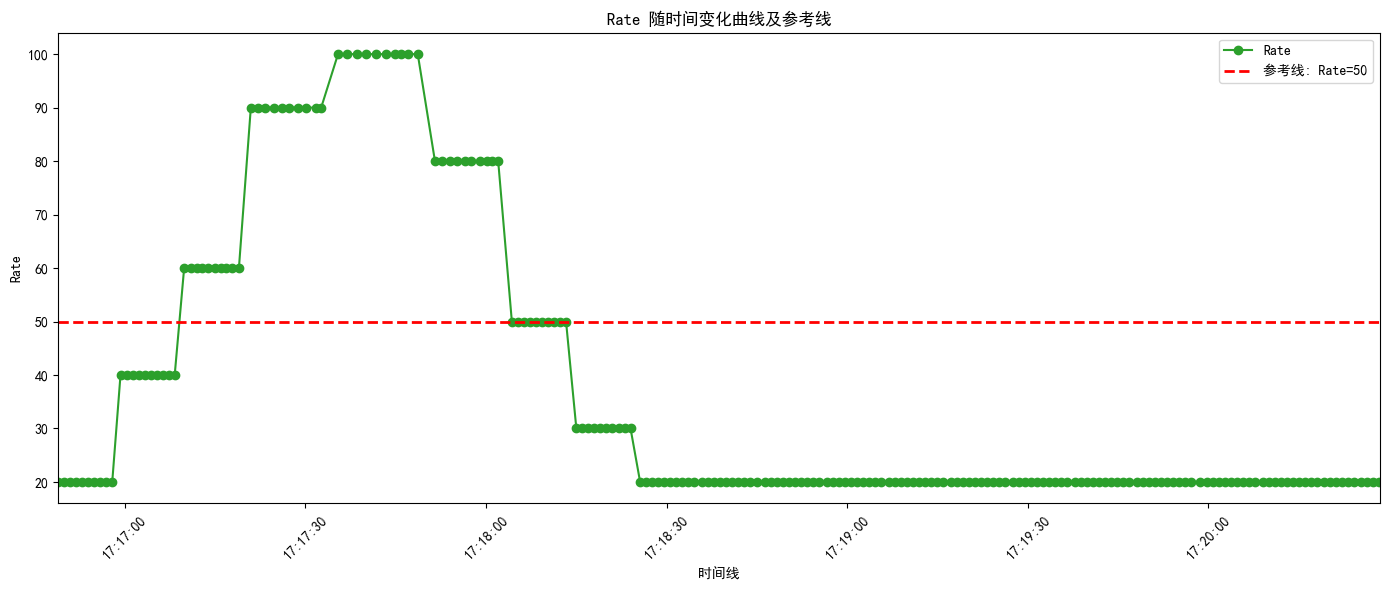

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

# 每隔10条采样一个点
sampled_data = consumer.iloc[::10].copy()

# 转换时间字段为 datetime 类型
sampled_data['timestamp'] = pd.to_datetime(sampled_data['timestamp'])

# 统一 loader 的时间戳为 datetime 类型
loader['timestamp'] = pd.to_datetime(loader['timestamp'])

# 统一时间范围（取 consumer 和 loader 的时间戳并集的最小-最大区间）
start_time = min(sampled_data['timestamp'].min(), loader['timestamp'].min())
end_time = max(sampled_data['timestamp'].max(), loader['timestamp'].max())

# 第一张图：Lag（左轴）和等待时间（右轴）
fig, ax1 = plt.subplots(figsize=(14, 6))

color_lag = 'tab:blue'
color_wait = 'tab:orange'

ax1.plot(sampled_data['timestamp'], sampled_data['lag'], label='Lag', marker='o', color=color_lag)
ax1.set_ylabel('Lag', color=color_lag)
ax1.tick_params(axis='y', labelcolor=color_lag)
ax1.set_xlim([start_time, end_time])

ax2 = ax1.twinx()
ax2.plot(sampled_data['timestamp'], sampled_data['wait_ms'], label='等待时间 (ms)', marker='o', color=color_wait)
ax2.set_ylabel('等待时间 (ms)', color=color_wait)
ax2.tick_params(axis='y', labelcolor=color_wait)

ax1.set_xlabel('时间线')
fig.suptitle('Lag 与等待时间(ms) 随时间变化曲线（双轴）')
fig.legend(['Lag', '等待时间 (ms)'], loc='upper right')
plt.xticks(rotation=45)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 第二张图：Rate 和参考线
plt.figure(figsize=(14, 6))
plt.plot(loader['timestamp'], loader['rate'], label='Rate', marker='o', color='tab:green')
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='参考线: Rate=50')
plt.xlabel('时间线')
plt.ylabel('Rate')
plt.title('Rate 随时间变化曲线及参考线')
plt.legend(loc='upper right')
plt.xlim([start_time, end_time])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
